In [1]:
#  import package and data, set wd
import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import matplotlib.image as mgimg
# from matplotlib.animation import FuncAnimation
import numpy as np
# from IPython.display import HTML
import os
import math
import pandas as pd

# set work directory
os.chdir('C:/Users/daizh/manuscript_GougeKinematics_different_evironment_conditions/python_file')

# data
from read_data_ver2 import *  # notice the version of readdata


D:\fault_sensor_data\PhotoElastic12_sensors\py_Earthquake2D_PhotoElastic14_P28_Esensor_PhotoElastic14_P28_f15_Vp5_E200_rst%02d.zip
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
done


In [2]:
# set wd
wd_ = 'C:/Users/daizh/manuscript_GougeKinematics_different_evironment_conditions/python_file'
os.chdir(wd_)

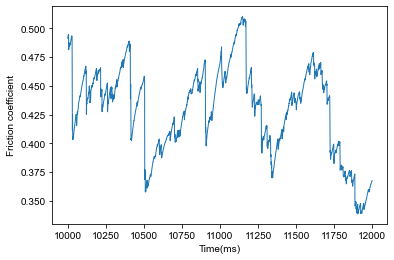

9999.999999199


In [3]:
# show which period we plot
index1_ = 7019

index2_ = index1_ + 2000
individuals_ =    [int(i_ * 2 + 1) for i_ in range(int(286/2))]


#%% plot the area we focus on
plt.rc('font', family = 'Arial')
plt.plot(ConSV_PlateBottomBeadMiddle_.loc[index1_:index2_, 'Time'],  \
         (ConSV_PlateBottomBeadMiddle_.loc[index1_:index2_,'fx'] - ConSV_PlateTopBeadMiddle_.loc[index1_:index2_,'fx'])/ \
         (ConSV_PlateTopBeadMiddle_.loc[index1_:index2_,'fy'] - ConSV_PlateBottomBeadMiddle_.loc[index1_:index2_,'fy']),\
         linewidth = 1)
plt.xlabel('Time(ms)')
plt.ylabel('Friction coefficient')
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.savefig('friction coefficient inset.svg', dpi=600, format='svg')
plt.show()

print(ConSV_PlateBottomBeadMiddle_.loc[index1_, 'Time'])

In [4]:
# make the matrix

v_upboundary_ = np.zeros([len(individuals_), int(index2_ - index1_)]) # up boundary velocity matrix
v_bottomboundary_ = np.zeros([len(individuals_), int(index2_ - index1_)])  # bottom boundary velocity matrix
number_ = np.zeros(len(individuals_))         # record the number of sensors
time_ = np.zeros(int(index2_ - index1_))      # record the correspond time data
for i_ in range(len(individuals_)):
    number_[i_] = i_
    
for index_ in range(int(index2_ - index1_)):
    for i_ in individuals_:
        v_upboundary_[int(i_/2), index_] = sensors_[i_].loc[index_ + index1_, 'vx']        # the velocity in up boundary
        v_bottomboundary_[int(i_/2), index_] = sensors_[i_- 1].loc[index_ + index1_, 'vx']  # the velocity in up boundary
    time_[index_] = sensors_[index_].loc[index_ + index1_, 'Time']

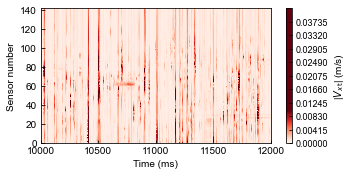

In [5]:
time_matrix_, number_matrix_= np.meshgrid(time_, number_)


fig = plt.figure(figsize=(5,2.52))
ax = fig.add_subplot()
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9
plt.rc('font', family = 'Arial')

plt.contourf(time_matrix_, number_matrix_, np.abs(v_upboundary_), levels = 1000, cmap = 'Reds', vmin = 0,vmax = 0.01 )

plt.ylabel('Sensor number', fontsize = 10)
plt.yticks([0,20,40,60,80,100,120,140])
plt.xlabel('Time (ms)', fontsize = 10)
plt.xticks([10000,10500, 11000,11500,12000])
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


cb = plt.colorbar()
cb.set_label(label = '|$\\mathit{V}$'+  '$_\\mathit{x}$' + '$_\\mathrm{t}$|'+ ' (m/s)', fontsize = 10)
# cb.set_ticks([0.0, 0.025, 0.050])
plt.tight_layout()
plt.savefig('notebook_plot/nucleation_up_80G.png', dpi=600, format='png')
plt.show()

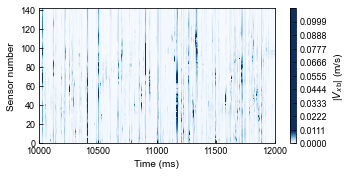

In [6]:
time_matrix_, number_matrix_= np.meshgrid(time_, number_)


fig = plt.figure(figsize=(5,2.52))
ax = fig.add_subplot()
plt.rc('font', family = 'Arial')
plt.rcParams['font.size'] = 9
plt.rc('font', family = 'Arial')

plt.contourf(time_matrix_, number_matrix_, np.abs(v_bottomboundary_), levels = 1000, cmap = 'Blues', vmin = 0,vmax = 0.01 )

plt.ylabel('Sensor number', fontsize = 10)
plt.yticks([0,20,40,60,80,100,120,140])
plt.xlabel('Time (ms)', fontsize = 10)
plt.xticks([10000,10500, 11000,11500,12000])
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


cb = plt.colorbar()
cb.set_label(label = '|$\\mathit{V}$'+  '$_\\mathit{x}$' + '$_\\mathrm{b}$|'+ ' (m/s)', fontsize = 10)
# cb.set_ticks([0.0, 0.025, 0.050])
plt.tight_layout()
plt.savefig('notebook_plot/nucleation_bottom_80G.png', dpi=600, format='png')
plt.show()

In [7]:
v_bottomboundary_

array([[ 6.63629233e-05,  1.11523675e-04,  1.45731487e-04, ...,
        -1.14934035e-05,  4.99260096e-05,  5.71268439e-05],
       [ 7.01353103e-05,  1.10105574e-04,  1.44329672e-04, ...,
        -1.22848931e-05,  5.36322720e-05,  6.21546819e-05],
       [ 8.37533525e-05,  1.07760829e-04,  1.39318293e-04, ...,
        -2.12421211e-05,  4.89542657e-05,  5.86870334e-05],
       ...,
       [ 3.13841343e-05,  1.07885820e-04,  7.03318648e-05, ...,
         5.18648101e-06,  3.52767660e-05,  6.15936750e-05],
       [ 3.01535741e-05,  1.10607850e-04,  6.81910695e-05, ...,
         7.45823828e-06,  3.65682307e-05,  6.24269211e-05],
       [ 3.02411332e-05,  1.12008567e-04,  6.67741915e-05, ...,
         6.19198490e-06,  3.65845677e-05,  6.24558304e-05]])

In [8]:
individuals_

[1,
 3,
 5,
 7,
 9,
 11,
 13,
 15,
 17,
 19,
 21,
 23,
 25,
 27,
 29,
 31,
 33,
 35,
 37,
 39,
 41,
 43,
 45,
 47,
 49,
 51,
 53,
 55,
 57,
 59,
 61,
 63,
 65,
 67,
 69,
 71,
 73,
 75,
 77,
 79,
 81,
 83,
 85,
 87,
 89,
 91,
 93,
 95,
 97,
 99,
 101,
 103,
 105,
 107,
 109,
 111,
 113,
 115,
 117,
 119,
 121,
 123,
 125,
 127,
 129,
 131,
 133,
 135,
 137,
 139,
 141,
 143,
 145,
 147,
 149,
 151,
 153,
 155,
 157,
 159,
 161,
 163,
 165,
 167,
 169,
 171,
 173,
 175,
 177,
 179,
 181,
 183,
 185,
 187,
 189,
 191,
 193,
 195,
 197,
 199,
 201,
 203,
 205,
 207,
 209,
 211,
 213,
 215,
 217,
 219,
 221,
 223,
 225,
 227,
 229,
 231,
 233,
 235,
 237,
 239,
 241,
 243,
 245,
 247,
 249,
 251,
 253,
 255,
 257,
 259,
 261,
 263,
 265,
 267,
 269,
 271,
 273,
 275,
 277,
 279,
 281,
 283,
 285]

In [9]:
np.max(v_upboundary_)

0.04142735064377